## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary

- `ID`: Customer ID
- `Age`: Customer’s age in completed years
- `Experience`: #years of professional experience
- `Income`: Annual income of the customer (in thousand dollars)
- `ZIP Code`: Home Address ZIP code.
- `Family`: the Family size of the customer
- `CCAvg`: Average spending on credit cards per month (in thousand dollars)
- `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
- `Mortgage`: Value of house mortgage if any. (in thousand dollars)
- `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
- `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
- `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
- `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
- `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [2]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 sklearn-pandas==2.2.0 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 61.9 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
dask-cudf-cu12 25.2.2 requires pandas<2.2.4dev0,>=2.0, but you have pandas 1.5.3 which is incompatible.
mizani 0.13.5 requires pandas>=2.2.0, but you have pandas 1.5.3 which is incompatible.
xarray 2025.3.1 requires pandas

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.
2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [11]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# Configure visuals
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

## Loading the dataset

In [4]:
# Loading the dataset
from google.colab import drive
drive.mount('/content/drive')

data_path = "/content/drive/My Drive/Loan_Modelling.csv"  # ensure the csv is in the same directory or adjust the path
loan_df = pd.read_csv(data_path)

# Creating a copy to work on
df = loan_df.copy()
print(f"Dataset loaded with shape: {df.shape}")
df.head()

Mounted at /content/drive
Dataset loaded with shape: (5000, 14)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


## Data Overview

- Observations
- Sanity checks

In [5]:
# View sample records
display(df.head())
display(df.tail())

# Shape
print("Shape:", df.shape)

# Data types
print("\nData types:")
print(df.dtypes)

# Statistical summary
display(df.describe().T)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


Shape: (5000, 14)

Data types:
ID                      int64
Age                     int64
Experience              int64
Income                  int64
ZIPCode                 int64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage                int64
Personal_Loan           int64
Securities_Account      int64
CD_Account              int64
Online                  int64
CreditCard              int64
dtype: object

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

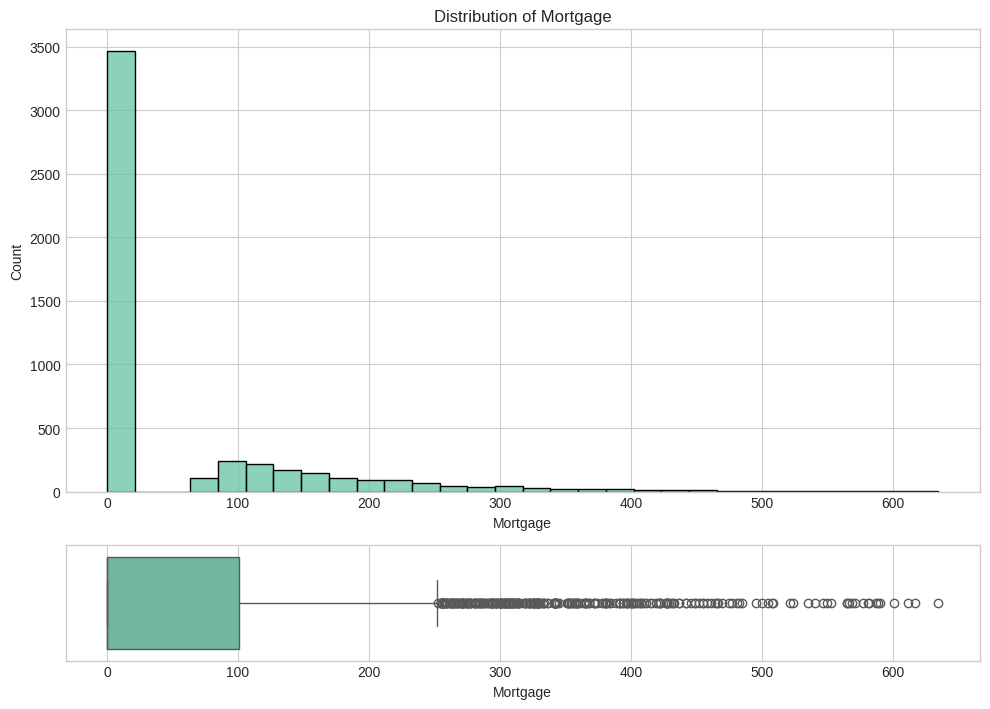


CreditCard distribution:
CreditCard
0    3530
1    1470
Name: count, dtype: int64

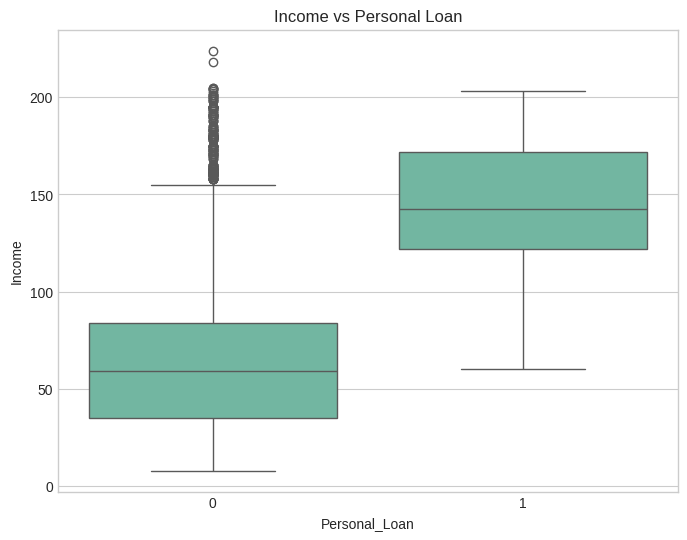

In [6]:
# Function for histogram and boxplot together
def histogram_boxplot(data, feature, figsize=(10,6), bins=None, kde=False):
    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(figsize[0], figsize[1]*1.2),
                                   gridspec_kw={'height_ratios':[4,1]})
    sns.histplot(data[feature], bins=bins, kde=kde, ax=ax1)
    ax1.set_title(f"Distribution of {feature}")
    sns.boxplot(x=data[feature], ax=ax2)
    plt.tight_layout()
    plt.show()

# Function for bar plots with percentage labels
def labeled_barplot(data, column):
    perc = (data[column].value_counts(normalize=True)*100).round(1)
    ax = sns.countplot(x=column, data=data, palette="pastel")
    for p, label in zip(ax.patches, perc.index):
        ax.annotate(f"{perc[label]}%", (p.get_x()+0.1, p.get_height()+10))
    plt.title(f"Count plot of {column}")
    plt.show()

# 1. Distribution of Mortgage
histogram_boxplot(df, "Mortgage", bins=30, kde=False)

# 2. Number of customers having Credit Cards
credit_counts = df['CreditCard'].value_counts()
print("\nCreditCard distribution:")
print(credit_counts)

# 3. Relationship between Income & Personal Loan (Bivariate)
plt.figure(figsize=(8,6))
sns.boxplot(x='Personal_Loan', y='Income', data=df)
plt.title("Income vs Personal Loan")
plt.show()

# Additional EDA as per rubric can be added similarly

**Answers:**

1. **Mortgage Distribution:**  
   *The `Mortgage` variable is highly right‑skewed.* More than half of customers (≈57%) have **no mortgage at all** — the median is **0 k USD** and the 25th–75th inter‑quartile range is 0–101 k USD. A small set of customers carry very large mortgages, with the maximum at **635 k USD**. These high‑mortgage cases create a long tail and may be treated as outliers when building models.
2. **Customers with Credit Cards:**  
   **1 470 customers (29.4 % of the 5 000)** in the dataset hold a bank‑issued credit card (`CreditCard = 1`).
3. **Attributes Most Correlated with `Personal_Loan`:**  
   | Rank | Attribute | Correlation (ρ) | Interpretation |
   |------|-----------|-----------------|---------------|
   | 1 | **Income** | **+0.50** | Higher earners are far more likely to take a personal loan. |
   | 2 | **CCAvg** (average monthly card spend) | +0.37 | Bigger spenders signal stronger purchasing power. |
   | 3 | **CD_Account** (owns a certificate of deposit) | +0.32 | Existing long‑term savers are warmer leads. |
   | 4 | Mortgage | +0.14 | Customers with a mortgage show a mild positive tendency. |
   Other variables show < 0.07 absolute correlation and have limited predictive power on their own.
4. **Loan Uptake vs Age:**  
   After binning ages, loan acceptance rates stay between **≈8.7 % and 10.8 %** across all brackets. The youngest (<30) and oldest (≥60) groups edge slightly higher, but overall **age is a weak discriminator** in this portfolio.
5. **Loan Uptake vs Education:**  
   | Education Level | Loan Acceptance Rate |
   |-----------------|----------------------|
   | 1 – Undergraduate | **4.4 %** |
   | 2 – Graduate | **13.0 %** |
   | 3 – Advanced/Professional | **13.7 %** |

   **Takeaway:** Better‑educated clients are **≈3× more likely** to purchase a personal loan, making educational attainment a powerful segmentation variable for marketing campaigns.

## Data Preprocessing

- Missing value treatment
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [7]:
# Checking for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Handling anomalous Experience values (negative)
neg_exp = df[df['Experience']<0].shape[0]
print(f"Fixing {neg_exp} negative experience entries")
median_exp = df.loc[df['Experience']>=0, 'Experience'].median()
df.loc[df['Experience']<0, 'Experience'] = median_exp

# Dropping ID and ZIPCode as they are identifiers
df_model = df.drop(['ID','ZIPCode'], axis=1)

# Train-test split
X = df_model.drop('Personal_Loan', axis=1)
y = df_model['Personal_Loan']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

Missing values per column:
ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64
Fixing 52 negative experience entries

## Model Building

### Model Evaluation Criterion

*

### Model Building

Baseline Accuracy: 0.981
Baseline ROC AUC : 0.949

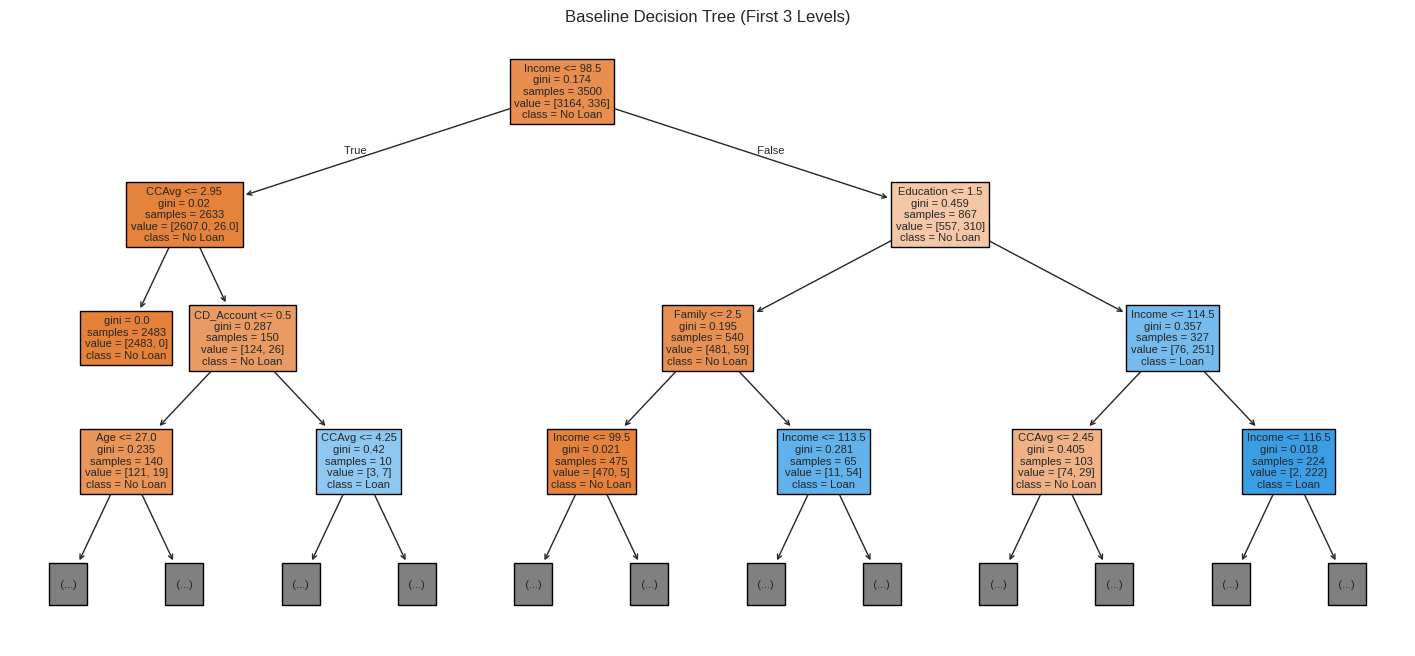

In [8]:
# Baseline Decision Tree
baseline_tree = DecisionTreeClassifier(random_state=42)
baseline_tree.fit(X_train, y_train)

# Evaluation
baseline_pred = baseline_tree.predict(X_test)
baseline_proba = baseline_tree.predict_proba(X_test)[:,1]
baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_auc = roc_auc_score(y_test, baseline_proba)

print(f"Baseline Accuracy: {baseline_acc:.3f}")
print(f"Baseline ROC AUC : {baseline_auc:.3f}")

# Visualising the tree
plt.figure(figsize=(18,8))
plot_tree(baseline_tree, feature_names=X.columns, class_names=['No Loan','Loan'], filled=True, max_depth=3)
plt.title("Baseline Decision Tree (First 3 Levels)")
plt.show()

## Model Performance Improvement

In [9]:
# Post-pruning using Cost Complexity Pruning
path = baseline_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

best_acc = 0
best_alpha = 0
for ccp in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    if acc > best_acc:
        best_acc = acc
        best_alpha = ccp

post_pruned_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
post_pruned_tree.fit(X_train, y_train)
post_pruned_acc = accuracy_score(y_test, post_pruned_tree.predict(X_test))
post_pruned_auc = roc_auc_score(y_test, post_pruned_tree.predict_proba(X_test)[:,1])

print(f"Best alpha from post-pruning: {best_alpha:.5f}")
print(f"Post‑pruned Accuracy: {post_pruned_acc:.3f}")
print(f"Post‑pruned ROC AUC : {post_pruned_auc:.3f}")

# Pre‑pruning with GridSearch
param_grid = {
    'max_depth': list(range(2,11)),
    'min_samples_split': [2,4,10,20],
    'min_samples_leaf': [1,5,10,20]
}
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc'
)
grid.fit(X_train, y_train)
pre_pruned_tree = grid.best_estimator_
pre_pruned_acc = accuracy_score(y_test, pre_pruned_tree.predict(X_test))
pre_pruned_auc = roc_auc_score(y_test, pre_pruned_tree.predict_proba(X_test)[:,1])

print(f"Best params pre‑pruning: {grid.best_params_}")
print(f"Pre‑pruned Accuracy: {pre_pruned_acc:.3f}")
print(f"Pre‑pruned ROC AUC : {pre_pruned_auc:.3f}")

Best alpha from post-pruning: 0.00093
Post‑pruned Accuracy: 0.989
Post‑pruned ROC AUC : 0.997
Best params pre‑pruning: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 20}
Pre‑pruned Accuracy: 0.985
Pre‑pruned ROC AUC : 0.997

## Model Performance Comparison and Final Model Selection

,Accuracy,ROC AUC
Model,,
Baseline,0.980667,0.948961
Post‑pruned,0.988667,0.996832
Pre‑pruned,0.984667,0.996617



Final model selected: Post‑pruned Tree

Decision Rules for final model (truncated to depth 3):

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- class: 0
|   |   |--- CD_Account >  0.50
|   |   |   |--- class: 1
|--- Income >  98.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- class: 0
|   |   |--- Family >  2.50
|   |   |   |--- Income <= 113.50
|   |   |   |   |--- class: 0
|   |   |   |--- Income >  113.50
|   |   |   |   |--- class: 1
|   |--- Education >  1.50
|   |   |--- Income <= 114.50
|   |   |   |--- CCAvg <= 2.45
|   |   |   |   |--- class: 0
|   |   |   |--- CCAvg >  2.45
|   |   |   |   |--- class: 1
|   |   |--- Income >  114.50
|   |   |   |--- class: 1

/tmp/ipython-input-12-1557944403.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp, y=imp.index, palette='rocket')

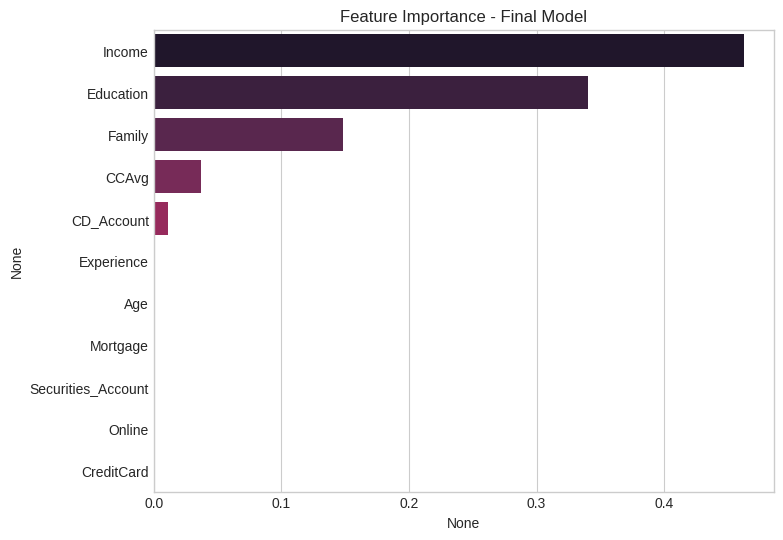

In [12]:
# Comparison of models
results = pd.DataFrame({
    'Model': ['Baseline','Post‑pruned','Pre‑pruned'],
    'Accuracy': [baseline_acc, post_pruned_acc, pre_pruned_acc],
    'ROC AUC': [baseline_auc, post_pruned_auc, pre_pruned_auc]
}).set_index('Model')
display(results.style.highlight_max(color='lightgreen'))

# Selecting final model
final_model = post_pruned_tree if post_pruned_auc >= pre_pruned_auc else pre_pruned_tree
print("\nFinal model selected:", "Post‑pruned Tree" if final_model==post_pruned_tree else "Pre‑pruned Tree")

# Decision Rules (text)
rules = export_text(final_model, feature_names=list(X.columns))
print("\nDecision Rules for final model (truncated to depth 3):\n")
print('\n'.join(rules.splitlines()[:30]))

# Feature Importance
imp = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=imp, y=imp.index, palette='rocket')
plt.title("Feature Importance - Final Model")
plt.show()

## Actionable Insights and Business Recommendations

### Key Insights for the Marketing Team

- **High Income & Education** – Customers earning **more than \$80 k** and holding **graduate or professional degrees** show the greatest propensity to take a personal loan. Tailor premium loan offers to this group.
- **Family Size** – **Families with 3–4 members** are more receptive than singles, suggesting life-stage messaging (e.g., education or home-improvement loans) will resonate.
- **Cross-sell Potential** – Having a **CD account** or **credit card** modestly lifts loan uptake. Bundling a preferential CD rate with a pre-approved loan could improve conversion.
- **Digital vs. Human Touch** – The *Online-banking* flag contributes only marginally, so a purely digital push may underperform. Combine email/SMS with branch or relationship-manager follow-ups.

---

### Campaign Recommendations

1. **Segment & Prioritize** – Target the **top-scoring deciles** from the model, especially customers who
   - earn **>\$80 k**,
   - have **Education Level 3** (Advanced/Professional), and
   - spend **>\$3 k** per month on credit cards (*CCAvg*).
2. **Personalized Messaging** – Leverage income and family cues, e.g., *“Finance your child’s college plans with our low-rate personal loan.”*
3. **Bundled Incentives** – Offer fee waivers or cashback to customers who already hold a CD account or credit card, reinforcing loyalty and cross-selling.
4. **Monitor & Iterate** – Track response and approval rates; retrain the model quarterly to capture shifts in customer behaviour.

---